In [1]:
import sys
sys.path.append('..')

from DataBaseAccess import DatabaseAccess
from Dividend_calculation_methods import constant
from implied_vol_calculator import ImpliedVolatilityCalculator
from volatility_surface import gaussian_smooth, cubic_spline
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

# =============================================================================
# # variables definition:
# =============================================================================
ticker = 'AAPL' # security to evaluate
date = '2020-10-05' #evaluation date

# initiating database access 

db_vendor = DatabaseAccess.createInstanceOfDatabaseAccess('Vendor', server ='PROD-VNDR-DB',
                                                          database = 'IvyDBUS',
                                                          username = 'tqa_user',
                                                          password = 'tqa_user')
# testing database connection
securityID = db_vendor.getSecurityIDFromTicker(ticker) # getting secutiry ID

ZC_curve_vendor = db_vendor.pullZCurve(date)
option_prices_vendor = db_vendor.pullOptionPricesTable(securityID, date)
vol_surface_raw = db_vendor.pullVolatilitySurfaceOfSecurityID(securityID, date)



In [3]:
ZC_curve_vendor

,Date,TTM,Rate,Quote,Inyears
0,2020-10-05,7,0.097971,0.000980,0.019178
1,2020-10-05,14,0.111607,0.001116,0.038356
2,2020-10-05,42,0.180825,0.001808,0.115068
3,2020-10-05,70,0.197709,0.001977,0.191781
4,2020-10-05,106,0.213194,0.002132,0.290411
5,2020-10-05,134,0.213133,0.002131,0.367123
6,2020-10-05,161,0.211394,0.002114,0.441096
7,2020-10-05,252,0.210094,0.002101,0.690411
8,2020-10-05,343,0.208139,0.002081,0.939726
9,2020-10-05,434,0.207004,0.002070,1.189041


In [4]:
option_prices_vendor

,Symbol,Date,Spot,IsIndex,Strike,TTM,YearFraction,CallPut,Expiration,ExerciseStyle,Bid,Ask,AveragePrice,Volume,OpenInterest,DBImpVol,DBDelta,DBGamma,DBVega,DBTheta
0,AAPL 201009C60000,2020-10-05,116.5,0,60.0,4,0.010959,C,2020-10-09,A,56.400002,56.599998,56.500000,25,143,-99.989998,-99.989998,-99.989998,-99.989998,-99.989998
1,AAPL 201009C65000,2020-10-05,116.5,0,65.0,4,0.010959,C,2020-10-09,A,51.400002,51.599998,51.500000,0,38,-99.989998,-99.989998,-99.989998,-99.989998,-99.989998
2,AAPL 201009C70000,2020-10-05,116.5,0,70.0,4,0.010959,C,2020-10-09,A,46.400002,46.599998,46.500000,2,40,-99.989998,-99.989998,-99.989998,-99.989998,-99.989998
3,AAPL 201009C75000,2020-10-05,116.5,0,75.0,4,0.010959,C,2020-10-09,A,41.450001,41.849998,41.650000,0,115,2.054117,0.984467,0.001560,0.476726,-44.733219
4,AAPL 201009C80000,2020-10-05,116.5,0,80.0,4,0.010959,C,2020-10-09,A,36.450001,36.700001,36.575001,0,158,1.614224,0.989546,0.001409,0.338787,-24.997869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2549,AAPL 230120P190000,2020-10-05,116.5,0,190.0,837,2.293151,P,2023-01-20,A,81.150002,83.699997,82.424999,0,0,0.366737,-0.722173,0.005016,57.208759,-4.191145
2550,AAPL 230120P195000,2020-10-05,116.5,0,195.0,837,2.293151,P,2023-01-20,A,85.500000,88.099998,86.799999,0,0,0.366166,-0.737734,0.004871,55.368160,-4.030253
2551,AAPL 230120P200000,2020-10-05,116.5,0,200.0,837,2.293151,P,2023-01-20,A,89.900002,92.550003,91.225002,0,8,0.365676,-0.752394,0.004722,53.599449,-3.869046
2552,AAPL 230120P210000,2020-10-05,116.5,0,210.0,837,2.293151,P,2023-01-20,A,98.849998,101.699997,100.274998,0,0,0.366292,-0.777726,0.004421,50.214218,-3.581572


In [5]:
vol_surface_raw

,SecurityID,Date,Days,Delta,CallPut,ImpliedVolatility,ImpliedStrike,ImpliedPremium,Dispersion
0,101594,2020-10-05,10,-90,P,0.392152,126.873398,10.719180,0.022919
1,101594,2020-10-05,10,-85,P,0.387738,124.772499,8.834101,0.013054
2,101594,2020-10-05,10,-80,P,0.387745,123.223503,7.530221,0.007663
3,101594,2020-10-05,10,-75,P,0.390590,121.951500,6.536152,0.007128
4,101594,2020-10-05,10,-70,P,0.395189,120.828102,5.726960,0.007726
...,...,...,...,...,...,...,...,...,...
369,101594,2020-10-05,730,70,C,0.407479,99.934547,32.906681,0.007002
370,101594,2020-10-05,730,75,C,0.412628,91.540199,37.506859,0.010562
371,101594,2020-10-05,730,80,C,0.420296,82.776390,42.919849,0.016469
372,101594,2020-10-05,730,85,C,0.431688,73.205658,49.529530,0.024490


In [6]:

#Selecciono los TTMs y strikes disponibles

TTMs = list(set(vol_surface_raw.Days.values))
TTMs.sort()

print(TTMs)

deltas = list(set(vol_surface_raw['Delta'].values))
deltas.sort()
print(deltas)

#CALLS
deltas = deltas[17:]

deltas


[10, 30, 60, 91, 122, 152, 182, 273, 365, 547, 730]
[-90, -85, -80, -75, -70, -65, -60, -55, -50, -45, -40, -35, -30, -25, -20, -15, -10, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90]


[10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90]

In [7]:
import numpy as np

implied_vols = np.zeros(shape = (len(deltas), len(TTMs)))

for i in range(len(deltas)):
    for j in range(1,len(TTMs)):
        try:
            implied_vols[i][j] = vol_surface_raw[(vol_surface_raw.Delta==deltas[i]) & (vol_surface_raw.Days==TTMs[j])].ImpliedVolatility.values[0]
            
        except:
            implied_vols[i][j] = 'Nan'
           
print(implied_vols)

[[0.         0.47360399 0.49351299 0.47402301 0.46696499 0.45963299
  0.456393   0.444783   0.43402201 0.41920099 0.41233799]
 [0.         0.45858699 0.47093999 0.455044   0.451859   0.447925
  0.445555   0.43515399 0.42542401 0.41265699 0.40771899]
 [0.         0.45390999 0.45685899 0.441293   0.440404   0.43848199
  0.43669099 0.42744699 0.41857699 0.407296   0.40404001]
 [0.         0.45502499 0.45256099 0.435294   0.434587   0.43311599
  0.431465   0.42227399 0.41358501 0.40345699 0.401553  ]
 [0.         0.457917   0.453428   0.434921   0.43320701 0.43149599
  0.42986301 0.41995299 0.410355   0.40088201 0.39985701]
 [0.         0.461458   0.45582899 0.43728    0.43401    0.43176901
  0.43014199 0.419846   0.40876299 0.399344   0.39863899]
 [0.         0.46549299 0.45839301 0.44044599 0.43595299 0.43301001
  0.43127799 0.42081001 0.40856099 0.398965   0.39794701]
 [0.         0.469733   0.461144   0.443501   0.43857199 0.43498299
  0.43301299 0.42204899 0.40925601 0.39983499 0.3980

In [8]:
import pandas as pd
df = pd.DataFrame(implied_vols, 
                  index = deltas, 
                  columns = TTMs)
df = df[df>0.00010]

#INTERPOLATE!
#df = df.interpolate(method='linear', axis=1)
#df = df.interpolate(method='linear', axis=0)


df = df.drop([df.columns[0]] ,  axis='columns')
TTMs_2=TTMs[1:]
df = df.dropna()

df

,30,60,91,122,152,182,273,365,547,730
10,0.473604,0.493513,0.474023,0.466965,0.459633,0.456393,0.444783,0.434022,0.419201,0.412338
15,0.458587,0.470940,0.455044,0.451859,0.447925,0.445555,0.435154,0.425424,0.412657,0.407719
20,0.453910,0.456859,0.441293,0.440404,0.438482,0.436691,0.427447,0.418577,0.407296,0.404040
25,0.455025,0.452561,0.435294,0.434587,0.433116,0.431465,0.422274,0.413585,0.403457,0.401553
30,0.457917,0.453428,0.434921,0.433207,0.431496,0.429863,0.419953,0.410355,0.400882,0.399857
35,0.461458,0.455829,0.437280,0.434010,0.431769,0.430142,0.419846,0.408763,0.399344,0.398639
40,0.465493,0.458393,0.440446,0.435953,0.433010,0.431278,0.420810,0.408561,0.398965,0.397947
45,0.469733,0.461144,0.443501,0.438572,0.434983,0.433013,0.422049,0.409256,0.399835,0.398054
50,0.473688,0.464354,0.446555,0.441549,0.437510,0.435226,0.423289,0.410271,0.401331,0.399009
55,0.477095,0.467855,0.449926,0.444863,0.440517,0.437904,0.424759,0.411465,0.402792,0.400411


In [9]:
deltas_new = df.index.values.tolist()
TTMs_new = df.columns.tolist()
df_np = df.to_numpy()

In [10]:
#Seteo de Matplotlib
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100
from mpl_toolkits import mplot3d

X, Y = np.meshgrid(TTMs_new,deltas_new)

Z = df_np


print('X', np.shape(X))
print('Y', np.shape(Y))
print('Z', np.shape(Z))

X (17, 10)
Y (17, 10)
Z (17, 10)


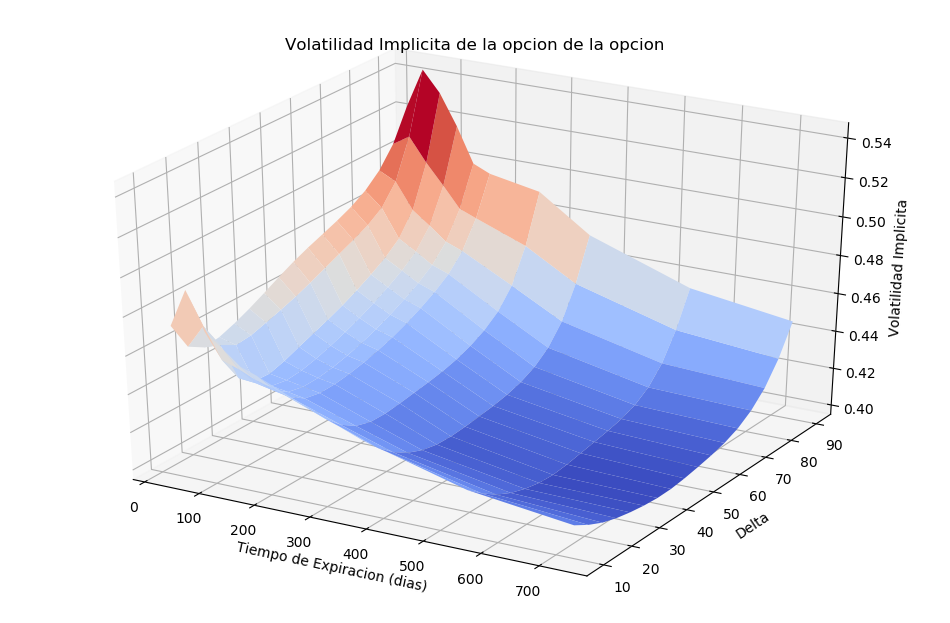

In [11]:
fig = plt.figure()

ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none')#rstride=1, cstride=1)
                

ax.set_title('Volatilidad Implicita de la opcion de la opcion');
ax.set_xlabel('Tiempo de Expiracion (dias)')
ax.set_ylabel('Delta')
ax.set_zlabel('Volatilidad Implicita')

plt.show()